## Resources

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
data_path = "/content/drive/MyDrive/ColabNotebooks/MasterML/Duckietown/bigCIL_dataset/"
this_folder = "/content/drive/MyDrive/ColabNotebooks/MasterML/Duckietown/CIL4/"

## Dataset Investigation

In [4]:
import os
import pandas as pd

image_extensions = ('.png', '.jpg', '.jpeg', '.gif', '.bmp', '.tiff')
image_count = 0

# Assuming images are in a subdirectory 'images' within data_path
images_dir = os.path.join(data_path, 'images')

if os.path.exists(images_dir):
    for root, _, files in os.walk(images_dir):
        for file in files:
            if file.lower().endswith(image_extensions):
                image_count += 1
else:
    print(f"Warning: '{images_dir}' not found. Please ensure your images are in the correct subdirectory.")

print(f"Total pictures found in '{images_dir}': {image_count}")

# Calculate 80/20 split
train_split = int(image_count * 0.8)
test_split = image_count - train_split

print(f"80/20 split: {train_split} for training, {test_split} for testing.")


Total pictures found in '/content/drive/MyDrive/ColabNotebooks/MasterML/Duckietown/bigCIL_dataset/images': 5284
80/20 split: 4227 for training, 1057 for testing.


In [5]:
csv_file_name = 'log.csv' # Corrected CSV file name
csv_path = os.path.join(data_path, csv_file_name)

if os.path.exists(csv_path):
    df = pd.read_csv(csv_path)
    num_rows_csv = len(df)
    print(f"Number of rows in '{csv_file_name}': {num_rows_csv}")
    # Check if number of rows matches image count + 1 (for header)
    if num_rows_csv == image_count + 1:
        print("Number of CSV rows matches image count + 1 (header). Headers are not included in the row count.")
    elif num_rows_csv == image_count:
        print("Number of CSV rows matches image count. There is no header.")
    else:
        print(f"Mismatch: CSV rows ({num_rows_csv}) do not match image count ({image_count}) + 1 header row. Please check your data.")
    display(df.head())
else:
    print(f"Error: CSV file '{csv_file_name}' not found at '{csv_path}'. Please specify the correct CSV file name or path.")

Number of rows in 'log.csv': 5284
Number of CSV rows matches image count. There is no header.


,timestamp,image_filename,vel_left,vel_right,intent,w,a,s,d
0,1.782133e+09,1782132766.9672.jpg,0.000000,0.000000,straight,0,0,0,0
1,1.782133e+09,1782132767.0649.jpg,0.000000,0.000000,straight,0,0,0,0
2,1.782133e+09,1782132767.1630.jpg,0.150827,0.175285,straight,1,0,0,0
3,1.782133e+09,1782132767.2630.jpg,0.150827,0.175285,straight,1,0,0,0
4,1.782133e+09,1782132767.3626.jpg,0.150827,0.175285,straight,1,0,0,0


In [6]:
if 'df' in locals() and not df.empty:
    if 'intent' in df.columns:
        print("\nOccurrences of each 'intent' value (in %):")
        intend_counts = df['intent'].value_counts(normalize=True) * 100
        print(intend_counts.to_string())
    else:
        print("Column 'intent' not found in the CSV.")
else:
    print("DataFrame not loaded or is empty. Cannot analyze 'intend' column.")


Occurrences of each 'intent' value (in %):
intent
straight    72.691143
left        17.978804
right        9.330053


In [7]:
if 'df' in locals() and not df.empty:
    control_columns = ['w', 'a', 's', 'd']
    print("\nPercentage of '1's in control columns (w, a, s, d):")
    for col in control_columns:
        if col in df.columns:
            # Assuming 0/1 binary values
            if df[col].isin([0, 1]).all():
                one_percentage = (df[col].sum() / len(df)) * 100
                print(f"  {col}: {one_percentage:.2f}%")
            else:
                print(f"  Warning: Column '{col}' contains values other than 0 or 1. Summing all non-zero values.")
                one_percentage = (df[col] != 0).sum() / len(df) * 100
                print(f"  {col}: {one_percentage:.2f}% (non-zero)")
        else:
            print(f"  Column '{col}' not found in the CSV.")
else:
    print("DataFrame not loaded or is empty. Cannot analyze control columns.")


Percentage of '1's in control columns (w, a, s, d):
  w: 99.74%
  a: 23.28%
  s: 0.00%
  d: 14.10%


In [8]:
if 'df' in locals() and not df.empty:
    if 'w' in df.columns and 'a' in df.columns:
        # Calculate co-occurrence of 'w' and 'a' being 1
        w_and_a_count = df[(df['w'] == 1) & (df['a'] == 1)].shape[0]
        w_and_a_percentage = (w_and_a_count / len(df)) * 100
        print(f"\nPercentage of times 'w' and 'a' are both 1: {w_and_a_percentage:.2f}%")
    else:
        print("Columns 'w' or 'a' not found in the CSV. Cannot calculate co-occurrence.")

    if 'w' in df.columns and 'd' in df.columns:
        # Calculate co-occurrence of 'w' and 'd' being 1
        w_and_d_count = df[(df['w'] == 1) & (df['d'] == 1)].shape[0]
        w_and_d_percentage = (w_and_d_count / len(df)) * 100
        print(f"Percentage of times 'w' and 'd' are both 1: {w_and_d_percentage:.2f}%")
    else:
        print("Columns 'w' or 'd' not found in the CSV. Cannot calculate co-occurrence.")
else:
    print("DataFrame not loaded or is empty. Cannot analyze co-occurrence.")


Percentage of times 'w' and 'a' are both 1: 23.28%
Percentage of times 'w' and 'd' are both 1: 14.10%


In [9]:
if 'df' in locals() and not df.empty:
    def get_action(row):
        if row['w'] == 1 and row['a'] == 0 and row['s'] == 0 and row['d'] == 0:
            return 0  # Straight
        elif row['w'] == 1 and row['a'] == 1 and row['s'] == 0 and row['d'] == 0:
            return 1  # Left
        elif row['w'] == 1 and row['d'] == 1 and row['s'] == 0 and row['a'] == 0:
            return 2  # Right
        else:
            return 3  # Other

    df['action'] = df.apply(get_action, axis=1)

    print("\nOccurrences of each 'action' value (in %):")
    action_counts = df['action'].value_counts(normalize=True) * 100
    print(action_counts.to_string())
else:
    print("DataFrame not loaded or is empty. Cannot create 'action' column.")


Occurrences of each 'action' value (in %):
action
0    62.358062
1    23.277820
2    14.099167
3     0.264951


## inspect segModel

ultralytics not found. Installing...
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.3/41.3 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 32.5 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Loading segmentation model from: /content/drive/MyDrive/ColabNotebooks/MasterML/Duckietown/CIL4/segModel.pt
Segmentation model loaded successfully (YOLO format).
Model is running on device: cpu
Using random example image from dataset: /content/drive/MyDrive/ColabNotebooks/MasterML/Duckietown/bigCIL_dataset/images/1782133038.9463.jpg

0: 480x640 37.1ms
Speed: 25.8ms preprocess, 37.1ms inference, 30.3ms postprocess per image at shape (1, 3, 480, 640)

--- Segmentation Model Output Inspection 

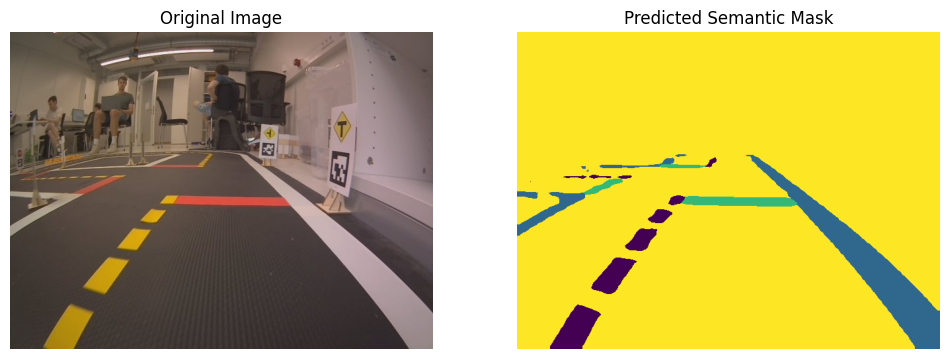

In [10]:
import os
import torch
from PIL import Image
import numpy as np
import random
import glob

# Ensure ultralytics is installed for YOLO model operations
try:
    from ultralytics import YOLO
except ImportError:
    print("ultralytics not found. Installing...")
    !pip install ultralytics
    from ultralytics import YOLO

# Define the path to the segmentation model based on user's request
seg_model_filename = 'segModel.pt'
seg_model_path = os.path.join(this_folder, seg_model_filename)

if not os.path.exists(seg_model_path):
    print(f"Error: Segmentation model '{seg_model_filename}' not found at {seg_model_path}.")
    print("Attempting to find 'best.pt' or 'last.pt' from a YOLO training run in 'this_folder'.")

    # Fallback to common YOLO saved model names
    fallback_paths = [
        os.path.join(this_folder, 'best.pt'),
        os.path.join(this_folder, 'last.pt'),
        # If the user trained a YOLO model, it might be in a 'runs' directory
        # This assumes a specific run name, which might not always be accurate
        # os.path.join(this_folder, 'runs', 'lane_marking_segmentation', 'weights', 'best.pt'),
        # os.path.join(this_folder, 'runs', 'lane_marking_segmentation', 'weights', 'last.pt'),
    ]
    found_fallback = False
    for fp in fallback_paths:
        if os.path.exists(fp):
            seg_model_path = fp
            seg_model_filename = os.path.basename(fp)
            print(f"Found fallback model: {seg_model_path}")
            found_fallback = True
            break

    if not found_fallback:
        raise FileNotFoundError(f"No segmentation model found at {seg_model_path} or common fallback paths. Please ensure your model is correctly saved and named.")

print(f"Loading segmentation model from: {seg_model_path}")

try:
    # Load the YOLO model
    model = YOLO(seg_model_path)
    print("Segmentation model loaded successfully (YOLO format).")
    print(f"Model is running on device: {model.device}")

    # Prepare an example image for inference
    example_img = None
    if 'images_dir' in globals() and os.path.exists(images_dir):
        # Check if images_dir actually contains image files
        image_files = [f for f in os.listdir(images_dir) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
        if image_files:
            random_image_path = os.path.join(images_dir, random.choice(image_files))
            print(f"Using random example image from dataset: {random_image_path}")
            example_img = Image.open(random_image_path).convert('RGB')
        else:
            print(f"No image files found in '{images_dir}'. Creating a dummy image.")

    if example_img is None:
        # From user context, imgsz=(480,640) was used for training (height, width)
        dummy_height, dummy_width = 480, 640
        print(f"Creating a dummy {dummy_width}x{dummy_height} RGB image for inference.")
        example_img = Image.new('RGB', (dummy_width, dummy_height), color='red') # PIL Image expects (width, height)

    # Perform inference
    results = model(example_img) # YOLO model handles resizing internally

    # Inspect the outputs if semantic_mask is present
    if results and hasattr(results[0], 'semantic_mask'):
        predicted_mask = results[0].semantic_mask.data # This is typically a torch.Tensor
        predicted_mask_numpy = predicted_mask.cpu().numpy()

        print(f"\n--- Segmentation Model Output Inspection ---")
        print(f"Original input image size (PIL): {example_img.size} (Width, Height)")
        print(f"Model output type (semantic_mask.data): {type(predicted_mask)}")
        print(f"Model output shape (semantic_mask.data): {predicted_mask.shape} (Batch, Height, Width)")
        print(f"Model output device (semantic_mask.data): {predicted_mask.device}")
        print(f"Model output data type (semantic_mask.data): {predicted_mask.dtype}")
        print(f"Unique values in predicted mask (on CPU): {np.unique(predicted_mask_numpy)}")

        # Basic visualization if matplotlib is available (no complex colormap assumed)
        import matplotlib.pyplot as plt
        plt.figure(figsize=(12, 6))
        plt.subplot(1, 2, 1)
        plt.imshow(example_img)
        plt.title('Original Image')
        plt.axis('off')

        plt.subplot(1, 2, 2)
        plt.imshow(predicted_mask_numpy)
        plt.title('Predicted Semantic Mask')
        plt.axis('off')
        plt.show()

    elif results:
        print("\nModel produced results, but 'semantic_mask' attribute was not found in the first result object.")
        print(f"Available attributes on results[0]: {[attr for attr in dir(results[0]) if not attr.startswith('__')]}")
        print("This might happen if the YOLO model was not specifically trained for segmentation or if the output format is different than expected.")
    else:
        print("Model inference returned no results.")

except Exception as e:
    print(f"An error occurred during model loading or inference: {e}")
    print("Please ensure ultralytics is installed and the model file is a valid YOLO segmentation model. Also check if the model architecture is compatible.")


## Training

### Utils

In [11]:
import torchvision.transforms as transforms
import os

# Ensure YOLO is imported from ultralytics
try:
    from ultralytics import YOLO
except ImportError:
    print("ultralytics not found. Installing...")
    !pip install ultralytics
    from ultralytics import YOLO

# Preprocessing Constants
CROP_TOP_ROWS = 175
INPUT_SHAPE = (112, 224) # Height, Width

# Intent mapping for one-hot encoding
INTENT_MAP = {
    "straight": [1.0, 0.0, 0.0, 0.0],
    "left":     [0.0, 1.0, 0.0, 0.0],
    "right":    [0.0, 0.0, 1.0, 0.0],
    "stop":     [0.0, 0.0, 0.0, 1.0]
}

def crop_image(pil_image):
    width, height = pil_image.size
    # Ensure cropping does not result in negative height
    crop_height = height - CROP_TOP_ROWS
    if crop_height <= 0:
        # If the image is too short, just return it or handle as an error
        print(f"Warning: Image height {height} is too small for CROP_TOP_ROWS {CROP_TOP_ROWS}. Not cropping.")
        return pil_image
    return pil_image.crop((0, CROP_TOP_ROWS, width, height))

# Transforms for segmentation masks (no augmentations as requested)
def get_train_mask_transforms():
    return transforms.Compose([
        transforms.Resize(INPUT_SHAPE, interpolation=transforms.InterpolationMode.NEAREST),
        transforms.ToTensor(), # Converts PIL to FLoatTensor and scales to [0.0, 1.0]
    ])

def get_eval_mask_transforms():
    return transforms.Compose([
        transforms.Resize(INPUT_SHAPE, interpolation=transforms.InterpolationMode.NEAREST),
        transforms.ToTensor(), # Converts PIL to FLoatTensor and scales to [0.0, 1.0]
    ])

def get_yolo_model(model_folder: str):
    """
    Loads the YOLO segmentation model from the specified folder.
    Includes fallback logic for common YOLO model names.
    """
    seg_model_filename = 'segModel.pt'
    seg_model_path = os.path.join(model_folder, seg_model_filename)

    if not os.path.exists(seg_model_path):
        # Fallback to common YOLO saved model names
        fallback_paths = [
            os.path.join(model_folder, 'best.pt'),
            os.path.join(model_folder, 'last.pt'),
        ]
        found_fallback = False
        for fp in fallback_paths:
            if os.path.exists(fp):
                seg_model_path = fp
                seg_model_filename = os.path.basename(fp)
                print(f"Using fallback YOLO model: {seg_model_path}")
                found_fallback = True
                break

        if not found_fallback:
            raise FileNotFoundError(f"No YOLO segmentation model found at {seg_model_path} or common fallback paths in {model_folder}.")

    print(f"Loading YOLO segmentation model from: {seg_model_path}")
    model = YOLO(seg_model_path) # Load as YOLO object
    model.eval() # Set to evaluation mode to freeze weights and disable dropout/batchnorm updates
    return model


### PilotNet Model

In [12]:
import torch
import torch.nn as nn

class ConditionalPilotNet(nn.Module):
    def __init__(self):
        super(ConditionalPilotNet, self).__init__()

        # Modified to accept 1 input channel (segmentation mask)
        self.feature_extractor = nn.Sequential(
            nn.Conv2d(1, 24, kernel_size=5, stride=2), nn.BatchNorm2d(24), nn.ReLU(),
            nn.Conv2d(24, 36, kernel_size=5, stride=2), nn.BatchNorm2d(36), nn.ReLU(),
            nn.Conv2d(36, 48, kernel_size=5, stride=2), nn.BatchNorm2d(48), nn.ReLU(),
            nn.Conv2d(48, 64, kernel_size=3, stride=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3, stride=1), nn.BatchNorm2d(64), nn.ReLU()
        )

        self.pool = nn.AdaptiveAvgPool2d((5, 10))
        # Adjusted flattened_size based on expected output after pooling
        self.flattened_size = 64 * 5 * 10

        # Define a smaller head architecture for each intent
        # Output is 4 neurons for classification (actions 0, 1, 2, 3)
        def create_smaller_head():
            return nn.Sequential(
                nn.Linear(self.flattened_size, 50),
                nn.ReLU(),
                nn.Dropout(0.3),
                nn.Linear(50, 10),
                nn.ReLU(),
                nn.Linear(10, 4) # Output 4 classification neurons
            )

        self.straight_head = create_smaller_head()
        self.left_head = create_smaller_head()
        self.right_head = create_smaller_head()
        self.default_head = create_smaller_head() # For 'stop' intent or other cases

    def forward(self, img, intent):
        # img is now expected to be the processed segmentation mask (1-channel tensor)
        x = self.feature_extractor(img)
        x = self.pool(x)
        x = x.reshape(-1, self.flattened_size)

        batch_size = x.size(0)
        outputs = torch.zeros(batch_size, 4, device=x.device)

        # Get boolean masks for each intent based on the one-hot encoding
        straight_mask = (intent[:, 0] == 1)
        left_mask = (intent[:, 1] == 1)
        right_mask = (intent[:, 2] == 1)
        stop_mask = (intent[:, 3] == 1) # Assuming index 3 for 'stop'

        # Apply corresponding head to the relevant part of the batch
        if straight_mask.any():
            outputs[straight_mask] = self.straight_head(x[straight_mask])
        if left_mask.any():
            outputs[left_mask] = self.left_head(x[left_mask])
        if right_mask.any():
            outputs[right_mask] = self.right_head(x[right_mask])
        if stop_mask.any(): # Handle 'stop' intent with the default head
            outputs[stop_mask] = self.default_head(x[stop_mask])

        return outputs


In [13]:
import torch
from PIL import Image
import torchvision.transforms as transforms

# Ensure YOLO is imported from ultralytics
try:
    from ultralytics import YOLO
except ImportError:
    print("ultralytics not found. Installing...")
    !pip install ultralytics
    from ultralytics import YOLO

# Assuming CROP_TOP_ROWS and INPUT_SHAPE are defined in cell b1396b34
# and crop_image is also defined there.

def inference_pipeline(raw_image: Image.Image, yolo_seg_model: YOLO, pilot_net_model: torch.nn.Module, intent_tensor: torch.Tensor, device: torch.device):
    """
    Executes the inference pipeline: raw image -> YOLO seg model -> processed mask -> ConditionalPilotNet.

    Args:
        raw_image (PIL.Image.Image): The input raw RGB image.
        yolo_seg_model (YOLO): The loaded YOLO segmentation model.
        pilot_net_model (torch.nn.Module): The loaded ConditionalPilotNet model.
        intent_tensor (torch.Tensor): The one-hot encoded intent vector (e.g., [1, 4] or [1, 4] batch).
        device (torch.device): The device to run inference on (e.g., 'cuda' or 'cpu').

    Returns:
        torch.Tensor: Predicted wheel velocities from the PilotNet.
    """
    # Ensure models are in evaluation mode
    yolo_seg_model.eval()
    pilot_net_model.eval()

    # --- 1. YOLO Segmentation Inference ---
    # YOLO model expects PIL Image and handles its own preprocessing/resizing internally
    yolo_results = yolo_seg_model(raw_image, verbose=False) # verbose=False to suppress output

    if not yolo_results or not hasattr(yolo_results[0], 'semantic_mask'):
        raise ValueError("YOLO model did not produce a semantic mask. Check model output and task.")

    # Extract the segmentation mask (torch.Tensor, e.g., [H, W], uint8)
    segmentation_mask_tensor = yolo_results[0].semantic_mask.data.cpu() # Move to CPU for PIL conversion

    # --- 2. Mask Preprocessing for PilotNet ---
    # Convert tensor mask to PIL Image (retains integer values)
    mask_pil = Image.fromarray(segmentation_mask_tensor.numpy())

    # Crop the mask (using the crop_image function from utils)
    cropped_mask_pil = crop_image(mask_pil)

    # Resize the mask to INPUT_SHAPE using nearest neighbor to preserve class labels
    # PIL.resize expects (width, height)
    resized_mask_pil = cropped_mask_pil.resize((INPUT_SHAPE[1], INPUT_SHAPE[0]), Image.NEAREST)

    # Convert the processed mask PIL Image to a PyTorch tensor
    # ToTensor will convert to float32 and scale to [0, 1]. For integer masks, this might need adjustment
    # if PilotNet expects specific integer class IDs, but typically it expects float input.
    processed_mask_tensor = transforms.ToTensor()(resized_mask_pil) # [1, H, W], float32

    # Add batch dimension and move to device for PilotNet
    processed_mask_input = processed_mask_tensor.unsqueeze(0).to(device) # [1, 1, H, W]

    # Ensure intent_tensor has a batch dimension if not already present
    if intent_tensor.ndim == 1:
        intent_input = intent_tensor.unsqueeze(0).to(device)
    else:
        intent_input = intent_tensor.to(device)

    # --- 3. ConditionalPilotNet Inference ---
    with torch.no_grad():
        predicted_velocities = pilot_net_model(processed_mask_input, intent_input)

    return predicted_velocities


In [14]:
# Count trainable parameters in the model
if 'ConditionalPilotNet' in locals():
    model_instance = ConditionalPilotNet()
    total_params = sum(p.numel() for p in model_instance.parameters() if p.requires_grad)
    print(f"Total trainable parameters in ConditionalPilotNet: {total_params}")
else:
    print("ConditionalPilotNet class not found. Please ensure it is defined before counting parameters.")

Total trainable parameters in ConditionalPilotNet: 773036


### Dataset

In [15]:
import os
import random
import torch
from torch.utils.data import Dataset
from PIL import Image
import torchvision.transforms.functional as TF

# Assumes ConditionalPilotNet, get_train_mask_transforms, get_eval_mask_transforms, crop_image, INTENT_MAP are defined above

class DuckieTownDataset(Dataset):
    def __init__(self, dataframe, image_dir, transform=None, yolo_model=None):
        self.dataframe = dataframe
        self.image_dir = image_dir
        self.transform = transform
        self.yolo_model = yolo_model

        if self.yolo_model is None:
            raise ValueError("YOLO segmentation model must be provided to the DuckieTownDataset.")
        self.yolo_model.eval() # Ensure YOLO model is in eval mode and frozen

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        # --- 1. Load Raw Image and Get Segmentation Mask from YOLO ---
        raw_img_name = os.path.join(self.image_dir, self.dataframe.iloc[idx]['image_filename'])
        raw_image = Image.open(raw_img_name).convert('RGB')

        with torch.no_grad(): # Ensure no gradients are computed for YOLO model
            yolo_results = self.yolo_model(raw_image, verbose=False)

        if not yolo_results or not hasattr(yolo_results[0], 'semantic_mask'):
            # Fallback or error handling if YOLO fails for a specific image
            print(f"Warning: YOLO failed for image {raw_img_name}. Skipping.")
            # You might want to return a dummy or skip this item entirely
            # For now, let's just create a black dummy mask and proceed
            # The size of the dummy mask should be compatible with YOLO output (e.g., 480x640)
            dummy_mask = torch.zeros(480, 640, dtype=torch.uint8) # Assuming common YOLO output size
            segmentation_mask_tensor = dummy_mask
        else:
            segmentation_mask_tensor = yolo_results[0].semantic_mask.data.cpu() # [H, W], uint8

        # Convert tensor mask to PIL Image (retains integer values)
        mask_pil = Image.fromarray(segmentation_mask_tensor.numpy())

        # --- 2. Get Target Action Label and Intent ---
        action_label = self.dataframe.iloc[idx]['action'] # Get the action label (0, 1, 2, 3)
        intent_str = self.dataframe.iloc[idx]['intent']

        target_label = torch.tensor(action_label, dtype=torch.long)
        intent_tensor = torch.tensor(INTENT_MAP.get(intent_str, [1.0, 0.0, 0.0, 0.0]), dtype=torch.float32)

        # --- 3. Apply Cropping to the MASK ---
        # Crop the mask (similar to how images were cropped)
        cropped_mask_pil = crop_image(mask_pil)

        # --- 4. Apply Final Transforms (Resize, ToTensor) to the MASK ---
        if self.transform:
            # This transform (get_train_mask_transforms or get_eval_mask_transforms)
            # will resize and convert the PIL mask to a [1, H, W] float32 tensor.
            processed_mask_tensor = self.transform(cropped_mask_pil)
        else:
            # If no transform, ensure it's still a tensor with correct shape
            processed_mask_tensor = transforms.ToTensor()(cropped_mask_pil) # Default conversion

        # The image returned is now the processed segmentation mask tensor
        return processed_mask_tensor, intent_tensor, target_label

### Training Script

In [16]:
import os
import time
import torch
import torch.optim as optim
import pandas as pd
from sklearn.model_selection import train_test_split
import torch.multiprocessing as mp
from torch.utils.data import WeightedRandomSampler # Import WeightedRandomSampler
from torch.optim.lr_scheduler import ReduceLROnPlateau # Import learning rate scheduler

# Assumes ConditionalPilotNet, DuckieTownDataset, get_train_mask_transforms, get_eval_mask_transforms, get_yolo_model are defined above

def train_model(data_path, epochs=10, batch_size=64, learning_rate=0.001):
    """Handles Data Loading, Training, Validation, and Saving PyTorch weights,
    and returns training/validation losses and accuracies for plotting.

    The ConditionalPilotNet is now trained on segmentation masks from a frozen YOLO model
    as a classification task.
    """
    # Set the multiprocessing start method to 'spawn' for CUDA compatibility
    # This needs to be called once at the beginning of the program if using multiprocessing with CUDA
    try:
        mp.set_start_method('spawn', force=True)
    except RuntimeError:
        pass # Already set

    images_folder = os.path.join(data_path, 'images')
    logs_filepath = os.path.join(data_path, 'log.csv')

    print("Loading dataset...")
    logs_df = pd.read_csv(logs_filepath)

    # Re-create the 'action' column as it's needed by the dataset
    def get_action(row):
        if row['w'] == 1 and row['a'] == 0 and row['s'] == 0 and row['d'] == 0:
            return 0  # Straight
        elif row['w'] == 1 and row['a'] == 1 and row['s'] == 0 and row['d'] == 0:
            return 1  # Left
        elif row['w'] == 1 and row['d'] == 1 and row['s'] == 0 and row['a'] == 0:
            return 2  # Right
        else:
            return 3  # Other
    logs_df['action'] = logs_df.apply(get_action, axis=1)

    train_df, val_df = train_test_split(logs_df, test_size=0.2, random_state=42)
    print(f"Training set: {len(train_df)} | Validation set: {len(val_df)}")

    # --- Oversampling for imbalanced intents in training data ---
    # Calculate class counts for the training dataframe
    intent_counts = train_df['intent'].value_counts()
    print("\nTraining intent distribution:\n", intent_counts)

    # Calculate inverse frequencies for each class to modestly emphasize underrepresented classes
    # This is a less drastic form of oversampling compared to using total_samples / count
    class_weights = {
        intent: 1.0 / count for intent, count in intent_counts.items()
    }
    print("Class weights for oversampling:\n", class_weights)

    # Create a list of weights for each sample in the training set
    sample_weights = [class_weights[intent] for intent in train_df['intent']]
    sampler = WeightedRandomSampler(torch.DoubleTensor(sample_weights), num_samples=len(train_df), replacement=True)

    # Load and freeze the YOLO segmentation model once
    # Use 'this_folder' as the location for segModel.pt as per previous context
    global this_folder
    yolo_seg_model = get_yolo_model(this_folder)
    yolo_seg_model.eval() # Ensure it's in evaluation mode and frozen
    print("YOLO segmentation model loaded and frozen for feature extraction.")

    train_dataset = DuckieTownDataset(
        train_df, images_folder, transform=get_train_mask_transforms(), yolo_model=yolo_seg_model
    )
    # Use the sampler for the train_loader instead of shuffle=True
    train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, sampler=sampler, num_workers=0)

    val_dataset = DuckieTownDataset(
        val_df, images_folder, transform=get_eval_mask_transforms(), yolo_model=yolo_seg_model
    )
    val_loader = torch.utils.data.DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=0)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = ConditionalPilotNet().to(device)
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    criterion = torch.nn.CrossEntropyLoss() # Changed to CrossEntropyLoss for classification

    # Initialize learning rate scheduler
    scheduler = ReduceLROnPlateau(optimizer, 'min', patience=5, factor=0.5)

    train_losses = []
    val_losses = []
    train_accuracies = [] # Added for classification accuracy
    val_accuracies = []   # Added for classification accuracy

    # Calculate initial validation loss and accuracy (performance of fresh initialized model)
    model.eval()
    initial_val_loss = 0.0
    correct_val_initial = 0
    total_val_initial = 0
    with torch.no_grad():
        for images, intents, targets in val_loader:
            images, intents, targets = images.to(device), intents.to(device), targets.to(device)
            outputs = model(images, intents)
            loss = criterion(outputs, targets)
            initial_val_loss += loss.item() * images.size(0)

            _, predicted = torch.max(outputs.data, 1)
            total_val_initial += targets.size(0)
            correct_val_initial += (predicted == targets).sum().item()

    initial_val_loss /= len(val_loader.dataset)
    initial_val_accuracy = correct_val_initial / total_val_initial
    val_losses.append(initial_val_loss) # Add to list for plotting
    val_accuracies.append(initial_val_accuracy)
    print(f"Initial Validation Loss: {initial_val_loss:.4f} | Initial Validation Accuracy: {initial_val_accuracy:.4f}")

    print(f"Training Started on device: {device}...")
    best_val_accuracy = 0.0 # Initialize for accuracy-based saving

    # Use 'this_folder' for saving models
    os.makedirs(this_folder, exist_ok=True) # Ensure the directory exists
    best_pth_path = os.path.join(this_folder, "best_model.pth")
    last_pth_path = os.path.join(this_folder, "last_model.pth")

    try:
        for epoch in range(epochs):
            epoch_start_time = time.time()

            # --- TRAIN ---
            model.train()
            running_train_loss = 0.0
            correct_train = 0
            total_train = 0
            for images, intents, targets in train_loader:
                images, intents, targets = images.to(device), intents.to(device), targets.to(device)

                optimizer.zero_grad()
                outputs = model(images, intents)
                loss = criterion(outputs, targets)
                loss.backward()
                optimizer.step()

                running_train_loss += loss.item() * images.size(0)
                _, predicted = torch.max(outputs.data, 1)
                total_train += targets.size(0)
                correct_train += (predicted == targets).sum().item()

            avg_train_loss = running_train_loss / len(train_loader.dataset)
            train_accuracy = correct_train / total_train
            train_losses.append(avg_train_loss)
            train_accuracies.append(train_accuracy)

            # --- VALIDATE ---
            model.eval()
            running_val_loss = 0.0
            correct_val = 0
            total_val = 0
            with torch.no_grad():
                for images, intents, targets in val_loader:
                    images, intents, targets = images.to(device), intents.to(device), targets.to(device)
                    outputs = model(images, intents)
                    loss = criterion(outputs, targets)
                    running_val_loss += loss.item() * images.size(0)

                    _, predicted = torch.max(outputs.data, 1)
                    total_val += targets.size(0)
                    correct_val += (predicted == targets).sum().item()

            avg_val_loss = running_val_loss / len(val_loader.dataset)
            val_accuracy = correct_val / total_val
            val_losses.append(avg_val_loss)
            val_accuracies.append(val_accuracy)
            epoch_duration = time.time() - epoch_start_time

            print(f"Epoch {epoch+1}/{epochs} | Train Loss: {avg_train_loss:.4f} | Train Acc: {train_accuracy:.4f} | Val Loss: {avg_val_loss:.4f} | Val Acc: {val_accuracy:.4f} | Time: {epoch_duration:.2f}s")

            # --- Step the learning rate scheduler ---
            scheduler.step(avg_val_loss)

            # --- SAVE BEST ---
            if val_accuracy > best_val_accuracy: # Changed condition to track accuracy
                best_val_accuracy = val_accuracy
                torch.save(model.state_dict(), best_pth_path)
                print(f"   [*] New best validation accuracy! Saved best_model.pth to {this_folder}")

    except KeyboardInterrupt:
        print("\nTraining interrupted by user. Saving current model state...")
    finally:
        # --- SAVE LAST --- Always save the last state if interrupted or finished
        torch.save(model.state_dict(), last_pth_path)
        print(f"Training Complete/Interrupted. Saved last_model.pth to {this_folder}")
        return train_losses, val_accuracies, val_losses, train_accuracies

    # This part is reached if training completes without interruption
    print(f"\nTraining Complete. Saved last_model.pth to {this_folder}")
    return train_losses, val_accuracies, val_losses, train_accuracies

## Training Pipeline Execution and Visualization

Loading dataset...
Training set: 4227 | Validation set: 1057

Training intent distribution:
 intent
straight    3058
left         772
right        397
Name: count, dtype: int64
Class weights for oversampling:
 {'straight': 0.0003270111183780249, 'left': 0.0012953367875647669, 'right': 0.0025188916876574307}
Loading YOLO segmentation model from: /content/drive/MyDrive/ColabNotebooks/MasterML/Duckietown/CIL4/segModel.pt
YOLO segmentation model loaded and frozen for feature extraction.
Initial Validation Loss: 1.3547 | Initial Validation Accuracy: 0.5270
Training Started on device: cuda...
Epoch 1/100 | Train Loss: 0.6206 | Train Acc: 0.7440 | Val Loss: 0.9327 | Val Acc: 0.7067 | Time: 92.67s
   [*] New best validation accuracy! Saved best_model.pth to /content/drive/MyDrive/ColabNotebooks/MasterML/Duckietown/CIL4/
Epoch 2/100 | Train Loss: 0.4491 | Train Acc: 0.8124 | Val Loss: 1.1889 | Val Acc: 0.6982 | Time: 91.02s
Epoch 3/100 | Train Loss: 0.3991 | Train Acc: 0.8308 | Val Loss: 0.8646

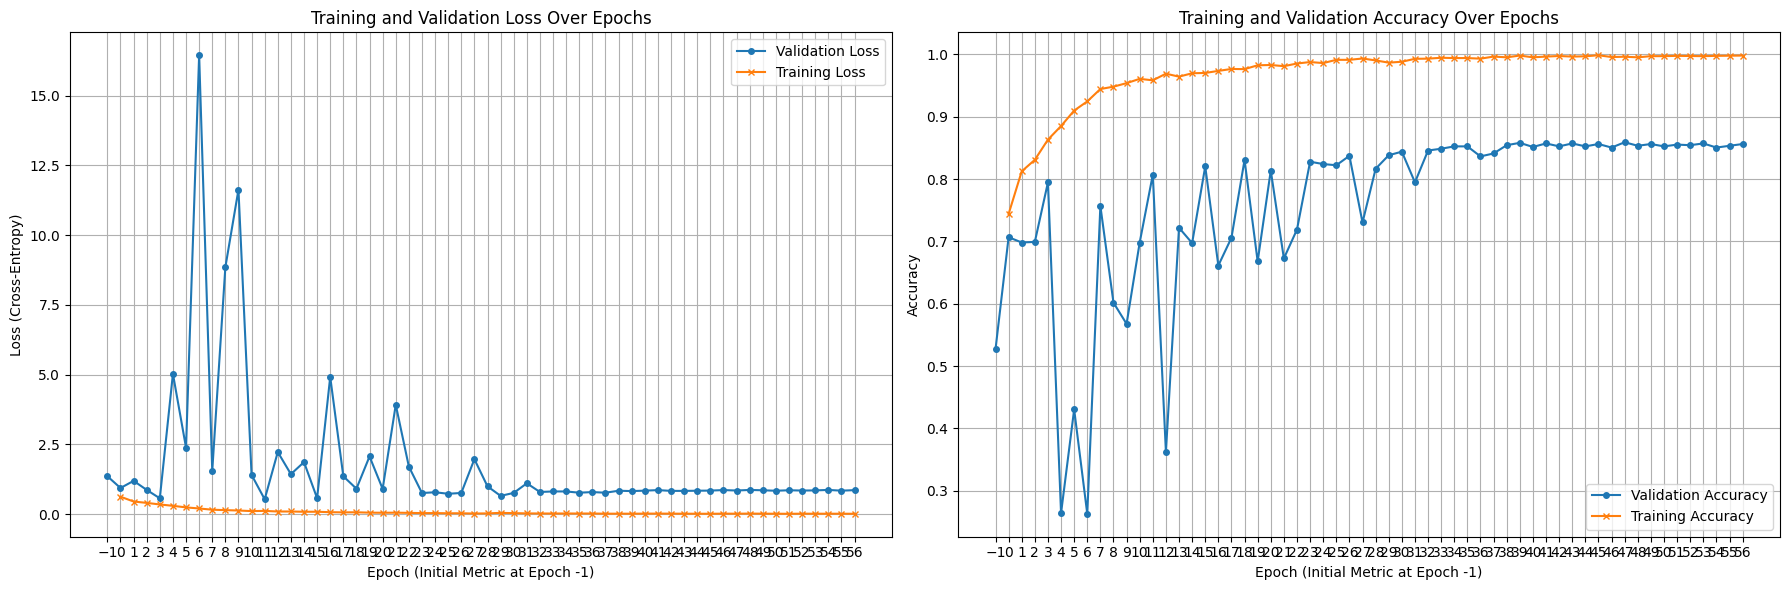

In [17]:
import matplotlib.pyplot as plt

# Call the train_model function and store the returned losses and accuracies
train_losses, val_accuracies, val_losses, train_accuracies = train_model(data_path, epochs=100, batch_size=64, learning_rate=0.001)

# Plotting Training and Validation Loss and Accuracy
if 'train_losses' in locals() and 'val_losses' in locals() and 'train_accuracies' in locals() and 'val_accuracies' in locals():
    # Epochs range needs to account for the initial validation metric (epoch -1)
    epochs_range = range(-1, len(train_losses)) # val_losses and val_accuracies include initial at index 0

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

    # Plot Loss
    ax1.plot(epochs_range, val_losses, label='Validation Loss', marker='o', markersize=4)
    ax1.plot(range(len(train_losses)), train_losses, label='Training Loss', marker='x', markersize=4)
    ax1.set_title('Training and Validation Loss Over Epochs')
    ax1.set_xlabel('Epoch (Initial Metric at Epoch -1)')
    ax1.set_ylabel('Loss (Cross-Entropy)')
    ax1.legend()
    ax1.grid(True)
    ax1.set_xticks(epochs_range)

    # Plot Accuracy
    ax2.plot(epochs_range, val_accuracies, label='Validation Accuracy', marker='o', markersize=4)
    ax2.plot(range(len(train_accuracies)), train_accuracies, label='Training Accuracy', marker='x', markersize=4)
    ax2.set_title('Training and Validation Accuracy Over Epochs')
    ax2.set_xlabel('Epoch (Initial Metric at Epoch -1)')
    ax2.set_ylabel('Accuracy')
    ax2.legend()
    ax2.grid(True)
    ax2.set_xticks(epochs_range)

    plt.tight_layout()
    plt.show()
else:
    print("Training and validation losses/accuracies not available for plotting. Please run `train_model` first.")

## Model Evaluation: Predictions on Example Images

In [20]:
import matplotlib.pyplot as plt
import numpy as np
import random
import torch
from PIL import Image
import os
import pandas as pd
from sklearn.model_selection import train_test_split

# Assumes ConditionalPilotNet, DuckieTownDataset, get_eval_mask_transforms, get_yolo_model, crop_image are defined above

# --- 1. Load ConditionalPilotNet model ---
model_path = os.path.join(this_folder, 'best_model.pth')

if not os.path.exists(model_path):
    print(f"Error: ConditionalPilotNet model not found at {model_path}. Please train the model first.")
    model = None
else:
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = ConditionalPilotNet().to(device)
    model.load_state_dict(torch.load(model_path, map_location=device))
    model.eval() # Set model to evaluation mode
    print(f"Loaded ConditionalPilotNet from {model_path}")

# --- 2. Load YOLO Segmentation Model ---
yolo_seg_model = None
try:
    yolo_seg_model = get_yolo_model(this_folder)
    yolo_seg_model.eval()
    print("YOLO segmentation model loaded for feature extraction.")
except FileNotFoundError as e:
    print(f"Error loading YOLO model: {e}")


if model and yolo_seg_model:
    # --- 3. Prepare a validation dataset and loader ---
    images_folder = os.path.join(data_path, 'images')
    logs_filepath = os.path.join(data_path, 'log.csv')
    logs_df = pd.read_csv(logs_filepath)

    # Re-create the 'action' column as it's needed by the dataset (copied from train_model)
    def get_action(row):
        if row['w'] == 1 and row['a'] == 0 and row['s'] == 0 and row['d'] == 0:
            return 0  # Straight
        elif row['w'] == 1 and row['a'] == 1 and row['s'] == 0 and row['d'] == 0:
            return 1  # Left
        elif row['w'] == 1 and row['d'] == 1 and row['s'] == 0 and row['a'] == 0:
            return 2  # Right
        else:
            return 3  # Other
    logs_df['action'] = logs_df.apply(get_action, axis=1)

    _, val_df = train_test_split(logs_df, test_size=0.2, random_state=42)

    # Instantiate DuckieTownDataset with the YOLO model
    val_dataset = DuckieTownDataset(val_df, images_folder, transform=get_eval_mask_transforms(), yolo_model=yolo_seg_model)

    print("Displaying predictions for 10 random validation images:")

    # Select 10 random indices from the validation set
    random_indices = random.sample(range(len(val_dataset)), 10)

    fig, axes = plt.subplots(10, 2, figsize=(15, 40))
    fig.suptitle('Model Predictions vs. Ground Truth (Validation Set)', y=1.02)

    with torch.no_grad():
        for i, idx in enumerate(random_indices):
            # The `image` from val_dataset is now the processed segmentation mask tensor
            processed_mask_tensor, intent_tensor, target_label = val_dataset[idx]

            # Load original raw image for display (before any processing)
            original_img_filename = val_dataset.dataframe.iloc[idx]['image_filename']
            original_img_path = os.path.join(val_dataset.image_dir, original_img_filename)
            original_raw_pil_image = Image.open(original_img_path).convert('RGB')

            # Optionally, get the intermediate cropped mask for visualization
            with torch.no_grad():
                yolo_results_vis = yolo_seg_model(original_raw_pil_image, verbose=False)
            intermediate_mask_tensor = yolo_results_vis[0].semantic_mask.data.cpu() # [H, W], uint8
            intermediate_mask_pil = crop_image(Image.fromarray(intermediate_mask_tensor.numpy()))


            # Add batch dimension and move to device for ConditionalPilotNet input
            image_input = processed_mask_tensor.unsqueeze(0).to(device) # [1, 1, H, W]
            intent_input = intent_tensor.unsqueeze(0).to(device) # [1, 4]

            # Make prediction
            output_logits = model(image_input, intent_input) # Model now outputs logits for 4 classes
            predicted_action = torch.argmax(output_logits, dim=1).cpu().item()

            # Ground Truth Action
            gt_action = target_label.cpu().item()

            # Check if prediction is correct
            is_correct = (predicted_action == gt_action)

            # Display
            ax0 = axes[i, 0]
            ax0.imshow(original_raw_pil_image)
            ax0.set_title(f"Raw Input Image: {original_img_filename}\nIntent: {val_dataset.dataframe.iloc[idx]['intent']}", fontsize=8)
            ax0.axis('off')

            ax1 = axes[i, 1]
            ax1.imshow(intermediate_mask_pil) # Display the cropped YOLO mask for context
            ax1.set_title(
                f"Cropped Mask\nGT Action: {gt_action}\nPred Action: {predicted_action}\nCorrect: {is_correct}", fontsize=8
            )
            ax1.axis('off')

    plt.tight_layout()
    plt.show()
else:
    print("Skipping model evaluation due to missing ConditionalPilotNet or YOLO model.")

Output hidden; open in https://colab.research.google.com to view.

### Export Script

In [21]:
import os
import torch

# Assumes ConditionalPilotNet is defined above

def compile_to_onnx(model_folder):
    """Loads saved PyTorch weights and exports them to ONNX format.
    Adjusted for 1-channel segmentation mask input.
    """
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = ConditionalPilotNet().to(device)
    model.eval() # Ensure dropout layers are disabled for export

    # Define exact dummy inputs expected by the model for 1-channel mask
    dummy_img = torch.randn(1, 1, INPUT_SHAPE[0], INPUT_SHAPE[1]).to(device) # [1, 1, Height, Width]
    dummy_intent = torch.randn(1, 4).to(device)

    # Compile Best Model
    best_pth = os.path.join(model_folder, "best_model.pth")
    if os.path.exists(best_pth):
        try:
            model.load_state_dict(torch.load(best_pth, map_location=device))
            torch.onnx.export(
                model, (dummy_img, dummy_intent), os.path.join(model_folder, "best_model.onnx"),
                export_params=True, opset_version=11, # Use opset 11 as previously requested implicitly
                input_names=['image_input', 'intent_input'], output_names=['wheel_velocities'],
                dynamic_axes={'image_input': {0: 'batch_size'}, 'intent_input': {0: 'batch_size'}, 'wheel_velocities': {0: 'batch_size'}} # Add dynamic axes for batch size
            )
            print(f"SUCCESS: Exported best_model.onnx to {model_folder}")
        except Exception as e:
            print(f"Error exporting best_model.onnx: {e}")

    # Compile Last Model
    last_pth = os.path.join(model_folder, "last_model.pth")
    if os.path.exists(last_pth):
        try:
            model.load_state_dict(torch.load(last_pth, map_location=device))
            torch.onnx.export(
                model, (dummy_img, dummy_intent), os.path.join(model_folder, "last_model.onnx"),
                export_params=True, opset_version=11, # Use opset 11 as previously requested implicitly
                input_names=['image_input', 'intent_input'], output_names=['wheel_velocities'],
                dynamic_axes={'image_input': {0: 'batch_size'}, 'intent_input': {0: 'batch_size'}, 'wheel_velocities': {0: 'batch_size'}} # Add dynamic axes for batch size
            )
            print(f"SUCCESS: Exported last_model.onnx to {model_folder}")
        except Exception as e:
            print(f"Error exporting last_model.onnx: {e}")


In [22]:
!pip install onnxscript
compile_to_onnx(this_folder)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 714.8/714.8 kB 17.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.1/19.1 MB 71.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 166.8/166.8 kB 18.2 MB/s eta 0:00:00


/tmp/ipykernel_3543/1801174340.py:23: UserWarning: # 'dynamic_axes' is not recommended when dynamo=True, and may lead to 'torch._dynamo.exc.UserError: Constraints violated.' Supply the 'dynamic_shapes' argument instead if export is unsuccessful.
  torch.onnx.export(
W0623 20:05:53.927000 3543 torch/onnx/_internal/exporter/_compat.py:133] Setting ONNX exporter to use operator set version 18 because the requested opset_version 11 is a lower version than we have implementations for. Automatic version conversion will be performed, which may not be successful at converting to the requested version. If version conversion is unsuccessful, the opset version of the exported model will be kept at 18. Please consider setting opset_version >=18 to leverage latest ONNX features


[torch.onnx] Obtain model graph for `ConditionalPilotNet([...]` with `torch.export.export(..., strict=False)`...


W0623 20:05:56.341000 3543 torch/fx/experimental/symbolic_shapes.py:8255] Unable to find user code corresponding to {u0}



def forward(self, arg0_1: "f32[24, 1, 5, 5]", arg1_1: "f32[24]", arg2_1: "f32[24]", arg3_1: "f32[24]", arg4_1: "f32[36, 24, 5, 5]", arg5_1: "f32[36]", arg6_1: "f32[36]", arg7_1: "f32[36]", arg8_1: "f32[48, 36, 5, 5]", arg9_1: "f32[48]", arg10_1: "f32[48]", arg11_1: "f32[48]", arg12_1: "f32[64, 48, 3, 3]", arg13_1: "f32[64]", arg14_1: "f32[64]", arg15_1: "f32[64]", arg16_1: "f32[64, 64, 3, 3]", arg17_1: "f32[64]", arg18_1: "f32[64]", arg19_1: "f32[64]", arg20_1: "f32[50, 3200]", arg21_1: "f32[50]", arg22_1: "f32[10, 50]", arg23_1: "f32[10]", arg24_1: "f32[4, 10]", arg25_1: "f32[4]", arg26_1: "f32[50, 3200]", arg27_1: "f32[50]", arg28_1: "f32[10, 50]", arg29_1: "f32[10]", arg30_1: "f32[4, 10]", arg31_1: "f32[4]", arg32_1: "f32[50, 3200]", arg33_1: "f32[50]", arg34_1: "f32[10, 50]", arg35_1: "f32[10]", arg36_1: "f32[4, 10]", arg37_1: "f32[4]", arg38_1: "f32[50, 3200]

[torch.onnx] Obtain model graph for `ConditionalPilotNet([...]` with `torch.export.export(..., strict=False)`... ❌
[torch.onnx] Obtain model graph for `ConditionalPilotNet([...]` with `torch.export.export(..., strict=True)`...


class GraphModule(torch.nn.Module):
    def forward(self, L_flat_args_0_: "f32[s6, 1, 112, 224][25088, 25088, 224, 1]cuda:0", L_flat_args_1_: "f32[s27, 4][4, 1]cuda:0"):
        l_flat_args_0_ = L_flat_args_0_
        l_flat_args_1_ = L_flat_args_1_

        # File: /tmp/ipykernel_3543/3351564825.py:40 in forward, code: x = self.feature_extractor(img)
        l__self____export_root_feature_extractor_0_weight: "f32[24, 1, 5, 5][25, 25, 5, 1]cuda:0" = self.L__self____export_root_feature_extractor_0_weight
        l__self____export_root_feature_extractor_0_bias: "f32[24][1]cuda:0" = self.L__self____export_root_feature_extractor_0_bias
        input_1: "f32[s6, 24, 54, 110][142560, 5940, 110, 1]cuda:0" = torch.conv2d(l_flat_args_0_, l__self____export_root_feature_extractor_0_weight, l__self____export_root_feature_extractor_0_bias, (2, 2), (0, 0), (1, 1), 1);  l_flat_args_0_ = l__self____export_root_feature_extractor_0_weight = l__self____export_root_feature_extractor_0_bias = None
        

[torch.onnx] Obtain model graph for `ConditionalPilotNet([...]` with `torch.export.export(..., strict=True)`... ❌
Error exporting best_model.onnx: Failed to export the model with torch.export. This is step 1/3 of exporting the model to ONNX. Next steps:
- Modify the model code for `torch.export.export` to succeed. Refer to https://pytorch.org/docs/stable/generated/exportdb/index.html for more information.
- Debug `torch.export.export` and submit a PR to PyTorch.
- Create an issue in the PyTorch GitHub repository against the *torch.export* component and attach the full error stack as well as reproduction scripts.

## Exception summary

<class 'torch.fx.experimental.symbolic_shapes.GuardOnDataDependentSymNode'>: Could not guard on data-dependent expression Eq(u0, 1) (unhinted: Eq(u0, 1)).  (Size-like symbols: none)

consider using data-dependent friendly APIs such as guard_or_false, guard_or_true and statically_known_true.
Caused by: (_export/non_strict_utils.py:1159 in __torch_function_

W0623 20:05:59.514000 3543 torch/fx/experimental/symbolic_shapes.py:8255] Unable to find user code corresponding to {u0}



def forward(self, arg0_1: "f32[24, 1, 5, 5]", arg1_1: "f32[24]", arg2_1: "f32[24]", arg3_1: "f32[24]", arg4_1: "f32[36, 24, 5, 5]", arg5_1: "f32[36]", arg6_1: "f32[36]", arg7_1: "f32[36]", arg8_1: "f32[48, 36, 5, 5]", arg9_1: "f32[48]", arg10_1: "f32[48]", arg11_1: "f32[48]", arg12_1: "f32[64, 48, 3, 3]", arg13_1: "f32[64]", arg14_1: "f32[64]", arg15_1: "f32[64]", arg16_1: "f32[64, 64, 3, 3]", arg17_1: "f32[64]", arg18_1: "f32[64]", arg19_1: "f32[64]", arg20_1: "f32[50, 3200]", arg21_1: "f32[50]", arg22_1: "f32[10, 50]", arg23_1: "f32[10]", arg24_1: "f32[4, 10]", arg25_1: "f32[4]", arg26_1: "f32[50, 3200]", arg27_1: "f32[50]", arg28_1: "f32[10, 50]", arg29_1: "f32[10]", arg30_1: "f32[4, 10]", arg31_1: "f32[4]", arg32_1: "f32[50, 3200]", arg33_1: "f32[50]", arg34_1: "f32[10, 50]", arg35_1: "f32[10]", arg36_1: "f32[4, 10]", arg37_1: "f32[4]", arg38_1: "f32[50, 3200]

[torch.onnx] Obtain model graph for `ConditionalPilotNet([...]` with `torch.export.export(..., strict=False)`... ❌
[torch.onnx] Obtain model graph for `ConditionalPilotNet([...]` with `torch.export.export(..., strict=True)`...
[torch.onnx] Obtain model graph for `ConditionalPilotNet([...]` with `torch.export.export(..., strict=True)`... ❌
Error exporting last_model.onnx: Failed to export the model with torch.export. This is step 1/3 of exporting the model to ONNX. Next steps:
- Modify the model code for `torch.export.export` to succeed. Refer to https://pytorch.org/docs/stable/generated/exportdb/index.html for more information.
- Debug `torch.export.export` and submit a PR to PyTorch.
- Create an issue in the PyTorch GitHub repository against the *torch.export* component and attach the full error stack as well as reproduction scripts.

## Exception summary

<class 'torch.fx.experimental.symbolic_shapes.GuardOnDataDependentSymNode'>: Could not guard on data-dependent expression Eq(u0, 1

class GraphModule(torch.nn.Module):
    def forward(self, L_flat_args_0_: "f32[s6, 1, 112, 224][25088, 25088, 224, 1]cuda:0", L_flat_args_1_: "f32[s27, 4][4, 1]cuda:0"):
        l_flat_args_0_ = L_flat_args_0_
        l_flat_args_1_ = L_flat_args_1_

        # File: /tmp/ipykernel_3543/3351564825.py:40 in forward, code: x = self.feature_extractor(img)
        l__self____export_root_feature_extractor_0_weight: "f32[24, 1, 5, 5][25, 25, 5, 1]cuda:0" = self.L__self____export_root_feature_extractor_0_weight
        l__self____export_root_feature_extractor_0_bias: "f32[24][1]cuda:0" = self.L__self____export_root_feature_extractor_0_bias
        input_1: "f32[s6, 24, 54, 110][142560, 5940, 110, 1]cuda:0" = torch.conv2d(l_flat_args_0_, l__self____export_root_feature_extractor_0_weight, l__self____export_root_feature_extractor_0_bias, (2, 2), (0, 0), (1, 1), 1);  l_flat_args_0_ = l__self____export_root_feature_extractor_0_weight = l__self____export_root_feature_extractor_0_bias = None
        